# Diabetes 130-US Hospitals — Initial Data Audit

**Project:** EHR Uncertainty / Selective Prediction  
**Dataset:** Diabetes 130-US Hospitals for Years 1999-2008  
**Source:** UCI Machine Learning Repository  
**UCI Dataset ID:** 296

## Purpose

This notebook performs an initial audit of the dataset before model development. The goal is to understand the dataset structure, target distribution, missingness, patient/encounter structure, and potential data-quality or leakage issues relevant to the project's investigation of predictive uncertainty and selective prediction.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Fetch Diabetes 130-US Hospitals dataset from UCI
diabetes = fetch_ucirepo(id=296)

# Separate features and target
X = diabetes.data.features
y = diabetes.data.targets

print("Dataset fetched successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

/opt/anaconda3/lib/python3.13/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset fetched successfully.
Features shape: (101766, 47)
Target shape:   (101766, 1)


In [3]:
print("Target columns:")
print(y.columns.tolist())

print("\nTarget distribution:")
print(y["readmitted"].value_counts())

print("\nTarget proportions:")
print(y["readmitted"].value_counts(normalize=True).round(4))

Target columns:
['readmitted']

Target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target proportions:
readmitted
NO     0.5391
>30    0.3493
<30    0.1116
Name: proportion, dtype: float64


In [4]:
df = pd.concat([X, y], axis=1)

print(f"Combined dataset shape: {df.shape}")
df.head()

Combined dataset shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print("Data types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Data types:


race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide           


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-

In [6]:
# Create local data directory if it does not exist
os.makedirs("../data/raw", exist_ok=True)

# Save the dataset locally for fast future access
df.to_csv("../data/raw/diabetic_data.csv", index=False)

print("Local dataset saved to data/raw/diabetic_data.csv")

Local dataset saved to data/raw/diabetic_data.csv


## 2. Missingness and Unknown Values

The dataset contains substantial missingness across several clinical and administrative variables. This section examines both pandas null values and categorical values that may represent unavailable, unknown, or unmapped information.

In [7]:
# Calculate missing values and percentages
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("missing_percent", ascending=False)
)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


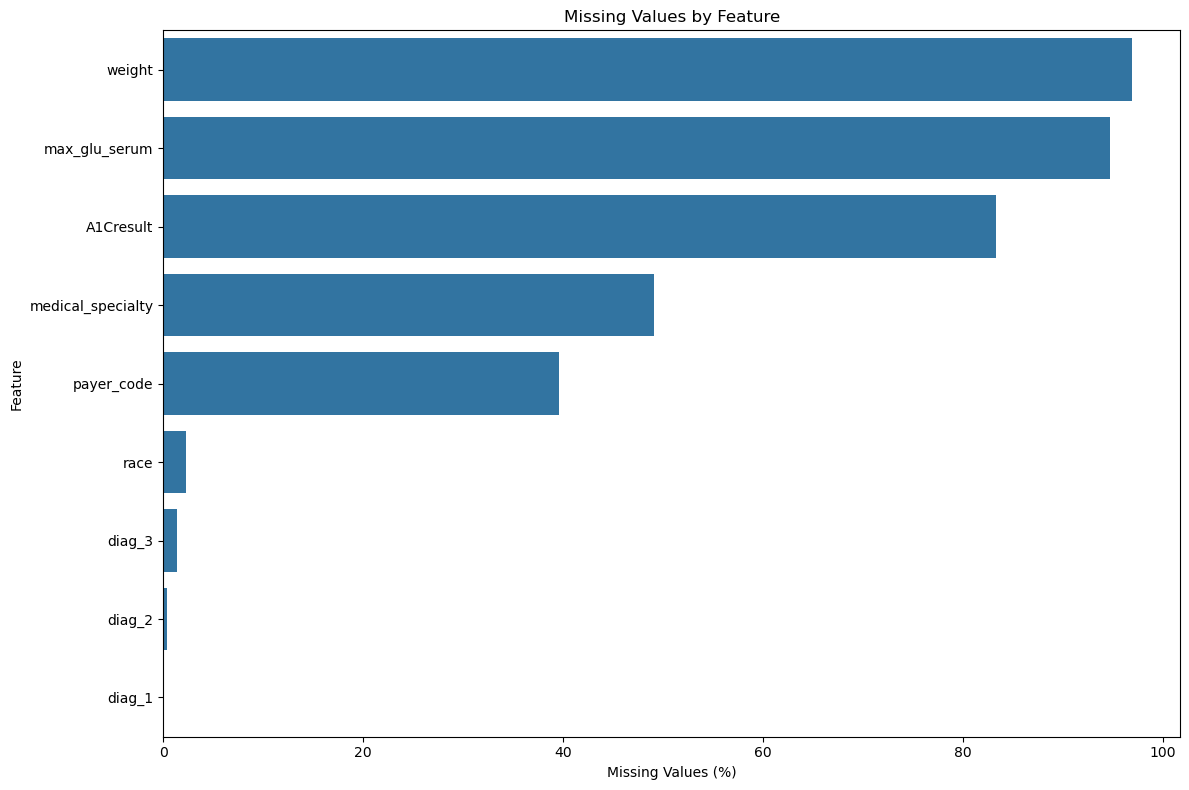

In [8]:
plt.figure(figsize=(12, 8))

missing_plot = missing_summary[missing_summary["missing_count"] > 0]

sns.barplot(
    x=missing_plot["missing_percent"],
    y=missing_plot.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()

In [9]:
# Inspect unique values for categorical/object columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(column)
    print(f"{'=' * 60}")
    print(df[column].value_counts(dropna=False).head(20))


race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

payer_code
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR     

In [10]:
## 3. High-Missingness Features

In [11]:
high_missing = missing_summary[missing_summary["missing_percent"] >= 20]

print(
    f"Number of features with at least 20% missing values: "
    f"{len(high_missing)}"
)

display(high_missing)

Number of features with at least 20% missing values: 5


,missing_count,missing_percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416


In [12]:
high_missing_columns = high_missing.index.tolist()

for column in high_missing_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(15))


weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

max_glu_serum
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

A1Cresult
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

medical_specialty
medical_specialty
NaN                                49949
InternalMedicine                   14635
Emergency/Trauma                    7565
Family/GeneralPractice              7440
Cardiology                          5352
Surgery-General                     3099
Nephrology                          1613
Orthopedics                         1400
Orthopedics-Reconstructive          1233
Radiologist                         1140
Pulmonology                          871
Psychiatry                           854
Urology                   